In [1]:
import getdist.plots as gdplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import cmocean

from pathlib import Path

import src.analysis.plots as plots

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)

pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

### Sources for $S_8$ measurements
-----------------------------------

https://academic.oup.com/mnras/article/505/4/5427/6293862 RSD+BAO+SNIa
- 0.762+0.030-0.025

https://iopscience.iop.org/article/10.3847/1538-4357/acfe06 ACT CMB Lensing
- 0.818\pm0.022 ACT Alone
- 0.813\pm0.018

https://arxiv.org/pdf/1807.06209 Planck Collaboration
- 0.832\pm0.013 TTTEEElowE + lensing
- 0.834\pm0.016 TTTEEElowE
- 0.825\pm0.011 TTTEEElowE + lensing + BAO

https://arxiv.org/abs/2503.19441 KiDS Legacy
- 0.815+0.016-0.021

https://arxiv.org/abs/2503.19442 KiDS Legacy x DES
- 0.818+0.012 −0.014

https://arxiv.org/abs/2007.15633 KiDS 1000
- 0.759+0.024-0.021

https://arxiv.org/abs/2304.00702 HSC Y3 Cosmic Shear (Real)
- 0.769+0.031-0.034

https://arxiv.org/abs/2304.00701 HSC Y3 Cosmic Shear (PS)
- 0.776+0.032-0.033

https://arxiv.org/abs/2507.01386 HSCxSDSS GC-WL
- 0.780+0.029-0.030

https://arxiv.org/abs/1809.09148 HSC Y1 Cosmic Shear
- 0.780+0.030_-0.033

https://arxiv.org/abs/2105.13549 DES Y3 3x2pt 
- 0.776+0.017-0.017

https://arxiv.org/pdf/2105.13544 DES Cosmic shear
- 0.772+0.018-0.017

https://inspirehep.net/literature/2901636 DES Y3 Cluster Abundances
- 0.864±0.035

https://arxiv.org/abs/2105.03421 WISE Planck CMB Lensing
- 0.784\pm0.015

https://arxiv.org/abs/2504.20038 Unified Planck ACT SPT CMB
- 0.825+0.015-0.013
- 0.828±0.012

https://arxiv.org/abs/2503.14452 ACT+Planck+DESI
-  S_8=0.8122\pm 0.0071

KiDS+DES+This work
- S8=0.813+0.009-0.010

All WL + CMB Lensing
- 0.818+/-0.007


In [2]:
### S8 constraints compared to other surveys
cmb_s8 = {
    #"ACT CMBL": [0.818, (0.022, 0.022)], 
    #r"unWISE$\,\times\,$Planck CMBL": [0.784, (0.015, 0.015)],
    #r"Planck$\,\times\,$ACT$\,\times\,$SPT CMBL": [0.825, (0.015, 0.013)],
    r"Planck$\,\times\,$ACT$\,\times\,$SPT (CMBL)": [0.828, (0.012, 0.012)],
    r"Planck$\,\times\,$ACT$\,\times\,$DESI DR2 (PS)" : [0.8122, (0.0071, 0.0071)]
    #"Planck TTTEEE" : [0.834, (0.016, 0.016)],
    #"Planck TTTEEE + lensing" : [0.832, (0.013, 0.013)],
    #"Planck TTTEEE + lensing + BAO" : [0.825, (0.011, 0.011)],
}
other_s8 = {
    #r"SNIa$\,\times\,$RSD$\,\times\,$BAO" : [0.762, (0.030, 0.025)], 
    #"DES Y3 Cluster Abundances" : [0.864, (0.035, 0.035)], 
} 
wl_s8 = {
    "KiDS-Legacy Cosmic Shear": [0.815, (0.016, 0.021)],
    #"KiDS-1000 Cosmic Shear": [0.759, (0.024, 0.021)], 
    #r"DES-Y3 3$\,\times\,$2pt": [0.776, (0.017, 0.017)],
    "DES-Y3 Cosmic Shear": [0.772, (0.018, 0.017)],
    "HSC-Y3 Cosmic Shear Real": [0.769, (0.031, 0.034)],
    "HSC-Y3 Cosmic Shear PS": [0.776, (0.032, 0.033)],
    #r"HSC-Y3$\,\times\,$SDSS GC-WL": [0.780, (0.029, 0.030)],
    #"HSC-Y1 Cosmic Shear": [0.780, (0.030, 0.033)],
    r"KiDS Legacy$\,\times\,$DES": [0.818, (0.012, 0.014)],
}
work_s8 = {
    r"[0.3-3]h$^{−1}$Mpc (pocoMC)" : [0.805, (0.018, 0.018)],
    r"[1-5]h$^{−1}$Mpc (pocoMC)" : [0.805, (0.016, 0.022)], #TODO
    "Real space, reweighted" : [0.810, (0.018, 0.021)],
    "Power Spectrum, reweighted" : [0.800, (0.029, 0.018)],
}
combined_s8 = {
    r"KiDS$\,\times\,$DES$\,\times\,$This$\;\;$work" : [0.813, (0.009, 0.010)], 
    r"WL$\,\times\,$CMB$\;\;$Lensing" : [0.818, (0.007, 0.007)], 
}

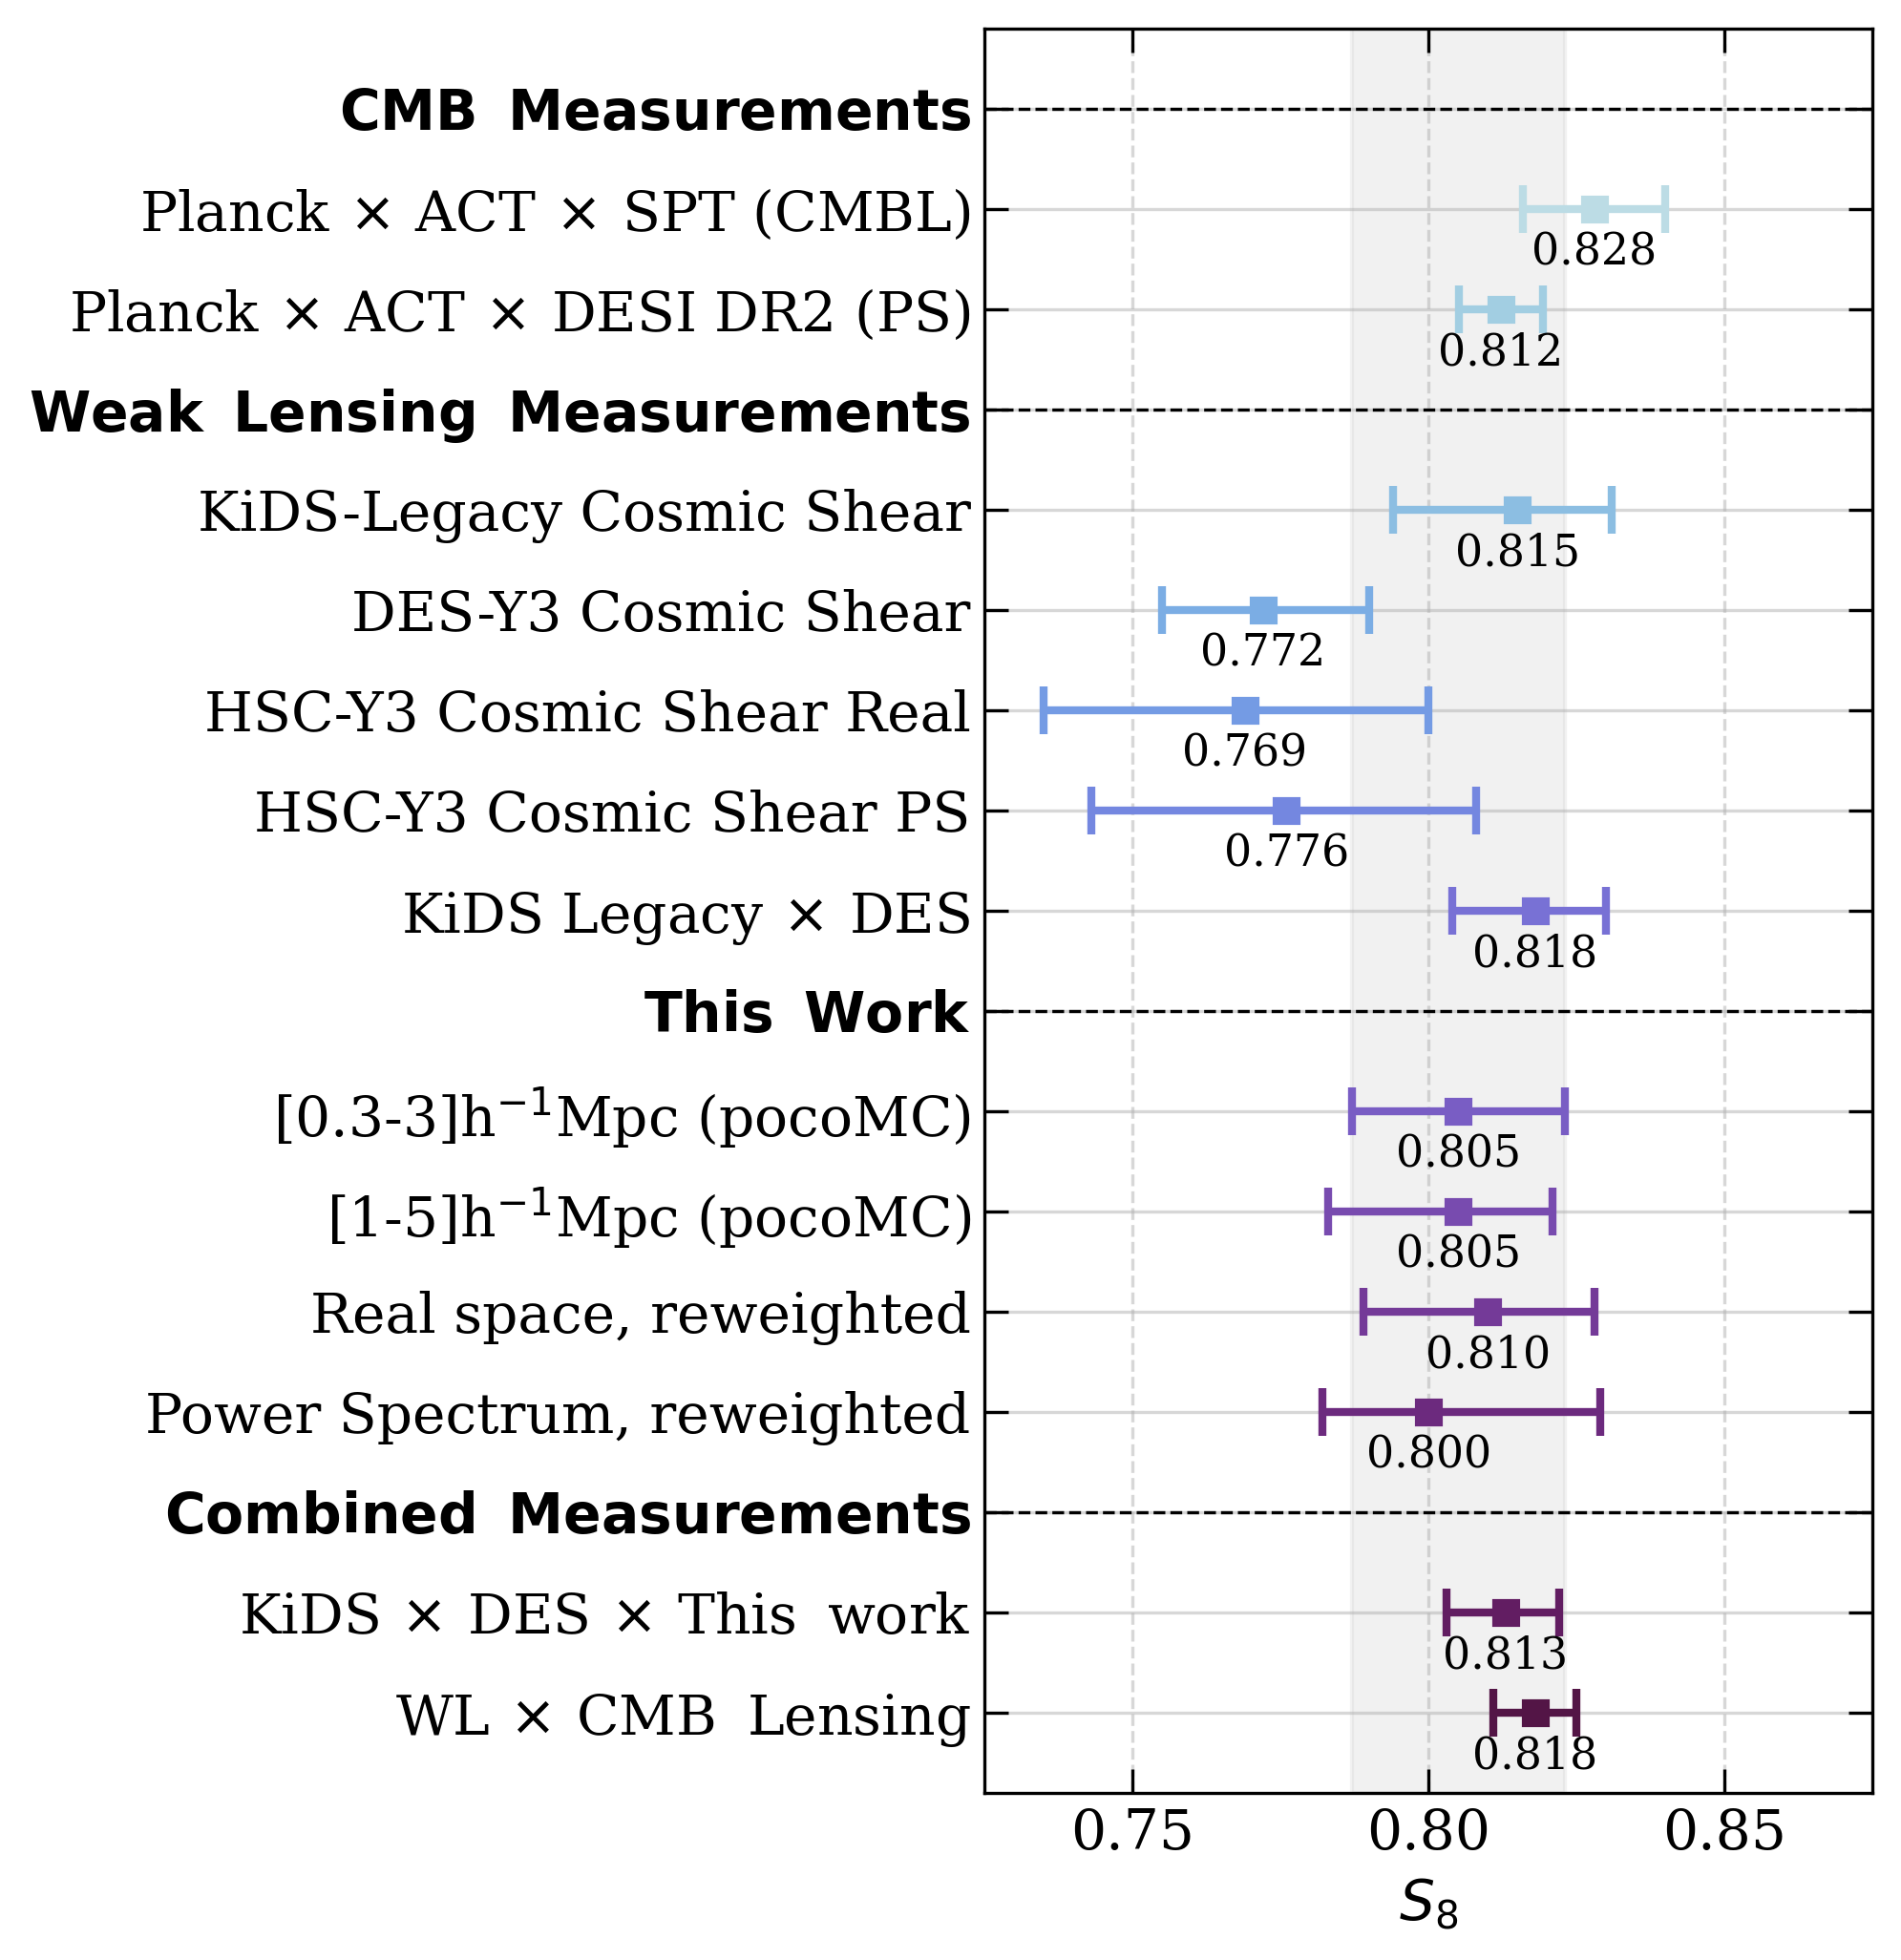

In [3]:
all_dicts = [cmb_s8, wl_s8, work_s8, combined_s8] #other_s8
titles = ["CMB\;\;Measurements", "Weak\;\;Lensing\;\;Measurements", "This\;\;Work", "Combined\;\;Measurements",] #"Other\;\;Measurements",

all_values = [val for d in all_dicts for val, _ in d.values()]
colors = cmocean.cm.dense(np.linspace(0.1, 0.9, len(all_values))) #ice_r

total_rows = sum(len(d) for d in all_dicts) + (len(all_dicts)-1)

with pm.make_plot("comparison_s8", figsize=(4, total_rows * 0.5), show=True, tight_layout=False) as (fig, ax):

    yticks = []
    ylabels = []
    ypos = 0
    color_idx = 0

    for idx, d in enumerate(all_dicts):

        yticks.append(ypos)
        ylabels.append(f"$\\bf{{{titles[idx]}}}$")
        ax.axhline(ypos, color='black', linestyle='--', linewidth=0.8)

        for key, (val, (err_up, err_down)) in d.items():
            ypos += 1
            ax.errorbar(
                val, ypos,
                xerr=[[err_down], [err_up]],
                fmt='s',
                color=colors[color_idx],
                elinewidth=2,
                markersize=6,
                capsize=6,
                capthick=2
            )
            ax.text(val, ypos + 0.65, f"{val:.3f}", ha='center', va='bottom', fontsize=11)
            yticks.append(ypos)
            ylabels.append(key)
            color_idx += 1
        ypos += 1

    work_val, (work_up, work_down) = work_s8[r"[0.3-3]h$^{−1}$Mpc (pocoMC)"]
    ax.axvspan(work_val - work_down, work_val + work_up, color='lightgray', alpha=0.3, label='This work')

    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=14)

    ax.invert_yaxis()
    ax.set_xlabel("$S_8$", fontsize=14)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.set_xlim(0.725, 0.875)